### <img src="../logoutn.jpg" align="right" width="150" /> 

#### Teoría de Circuitos II

# Tarea Semanal 3

Farcy Facundo


In [12]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
@author: facu
"""

#-------------------------
# IMPORTACIÓN DE MÓDULOS Y CONFIGURACIONES PREVIAS
#------------------------
# Módulos externos

import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

# módulo de SciPy
from scipy import signal as sig

# Esta parte de código la agregamos SOLO en los notebooks para fijar el estilo de los gráficos.
fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi
fig_font_size = 13
#_=plt.grid(True, which="both")
mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

from pytc2.sistemas_lineales import analyze_sys, bodePlot, pzmap, pretty_print_bicuad_omegayq, pretty_print_SOS, plot_plantilla, tf2sos_analog
from pytc2.general import print_latex, a_equal_b_latex_s

import matplotlib.patches as patches
from matplotlib.path import Path


## ÍTEMS 1 - 5

In [13]:
from IPython.display import IFrame
IFrame("TS3.pdf", width=1000, height=1000)


La simulación en ltspice se realizó variando la tolerancia de C, utilizando para definir C la función montecarlo,y se estudio la variación de w0. Para esto, se simuló la salida, buscando el punto donde la fase es 90°.
<img src="Spice1.png">

#### tolerancia 0.01
<img src="Spice2.png">
<img src="Spice2_zoom.png">

### tolerancia 0.05
<img src="Spice3.png">
<img src="Spice3_zoom.png">

#### tolerancia 0.1
<img src="Spice4.png">
<img src="Spice4_zoom.png">

Como se puede observar, a mayor tolerancia de C se puede ver efectivamente una mayor disperción en w0.
Además, si se analiza la fórmula de w0, R2 no influye. Por ende
\begin{equation}
S^{R2}_{\omega_0} = 0
\end{equation}
Por ende, podríamos comparar graficando con una C sin tolerancia, pero si con tolerancia en R2 usando un montecarlo. Para ese caso llegamos a lo siguiente:
<img src="Spice5.png">
<img src="Spice5_zoom.png">
Efectivamente, se puede observar como todas las curvas coinciden para los 90°, siendo indicador de que no varía la w0

### BONUS 1-3

In [14]:
IFrame("TS3_bonus.pdf", width=1000, height=1000)

#----------------------
# INICIO DEL CÓDIGO
#--------------------

En python, las transferencias normalizadas y desnormalizadas quedarían...

In [17]:
# Comienzo de la simulación
oh_w=1e-3/1e-9
oh_y=1e-3

g1=0;g2=1;g3=2;
cond=[1.,np.sqrt(2),1.]
c=0;
cap=[1.]

cond=np.array(cond);
cap=np.array(cap);

# Cargamos la funcion transferencia como vectores de sus coeficientes.
num = np.array([((cond[g3]/cap[c])**2)*cond[g1]/cond[g3]*(-1.)]);
den = np.array([1., cond[g2]/cap[c],(cond[g3]/cap[c])**2]);
H1 = sig.TransferFunction( num, den )
print("Transferencia normalizada")
pretty_print_bicuad_omegayq(num,den)#Desnormalizo
cond=cond/oh_y
cap=cap*oh_y/oh_w
num_des = np.array([((cond[g3]/cap[c])**2)*cond[g1]/cond[g3]*(-1.)]);
den_des = np.array([ 1., cond[g2]/cap[c],(cond[g3]/cap[c])**2]);
H1_des = sig.TransferFunction( num_des, den_des )
# mostramos la transferencia construida
print("Transferencia desnormalizada")
pretty_print_bicuad_omegayq(num_des,den_des)

Transferencia normalizada


<IPython.core.display.Math object>

Transferencia desnormalizada


<IPython.core.display.Math object>

Cuya simulación en python nos da lo siguiente:


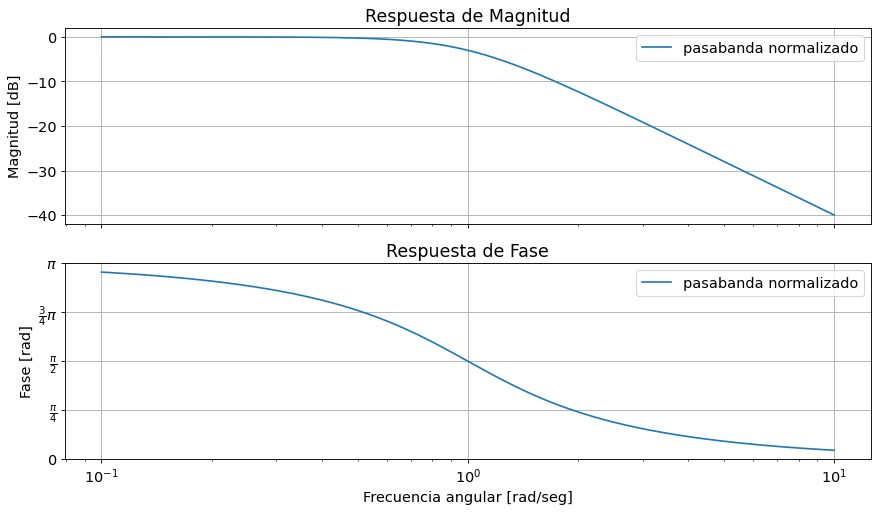

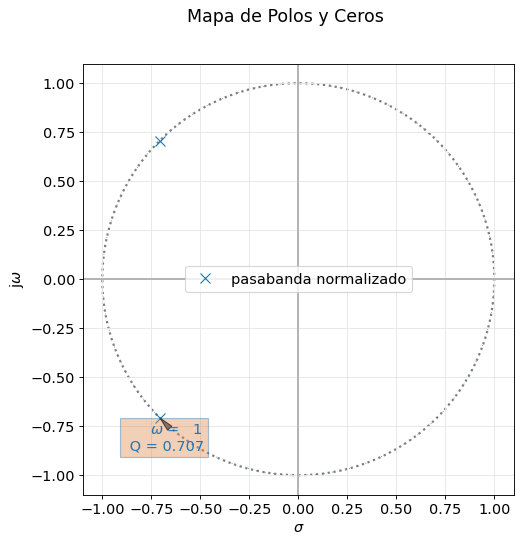

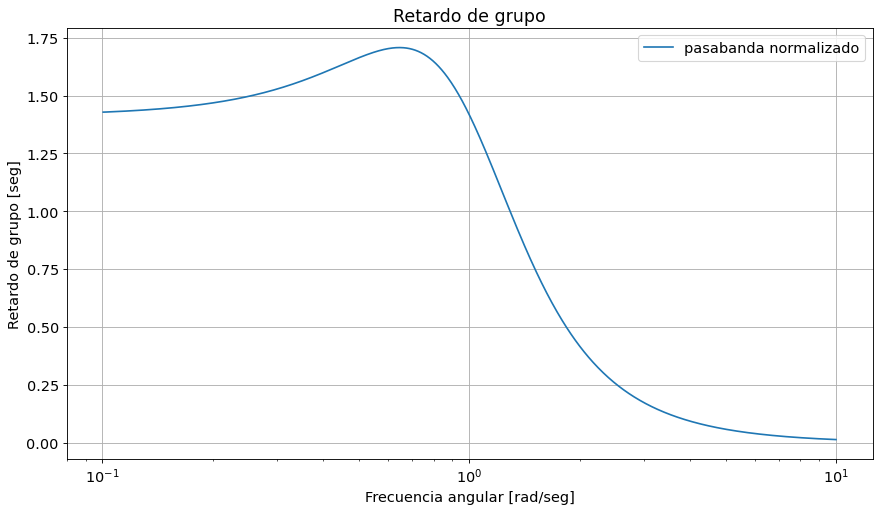

In [33]:
a = analyze_sys([H1], sys_name='pasabanda normalizado')

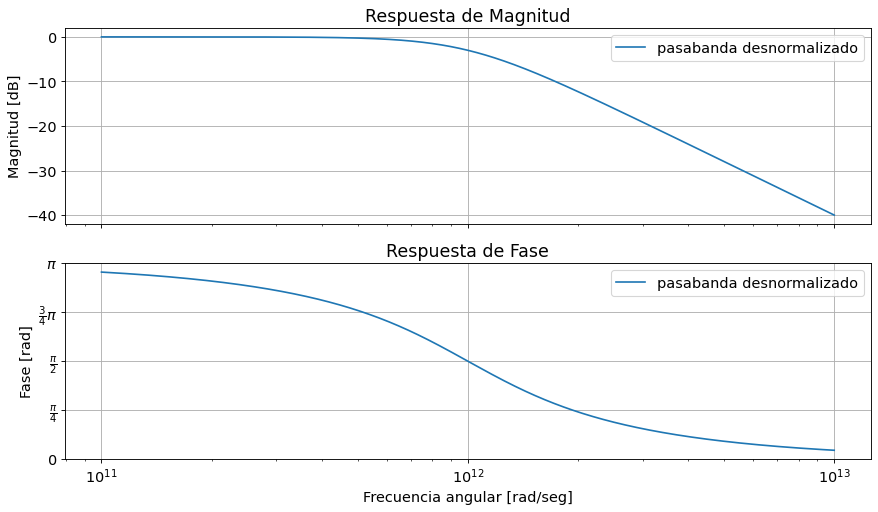

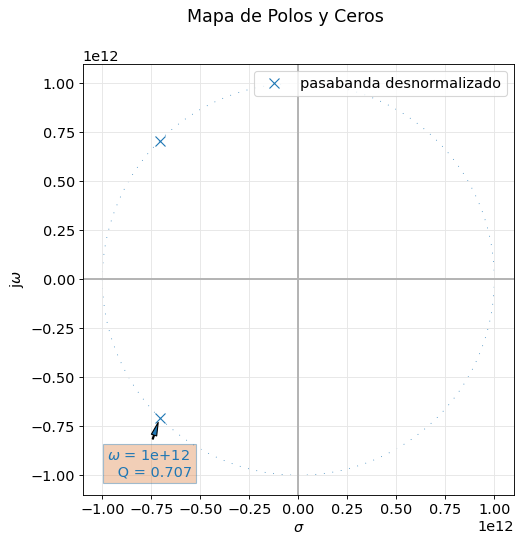

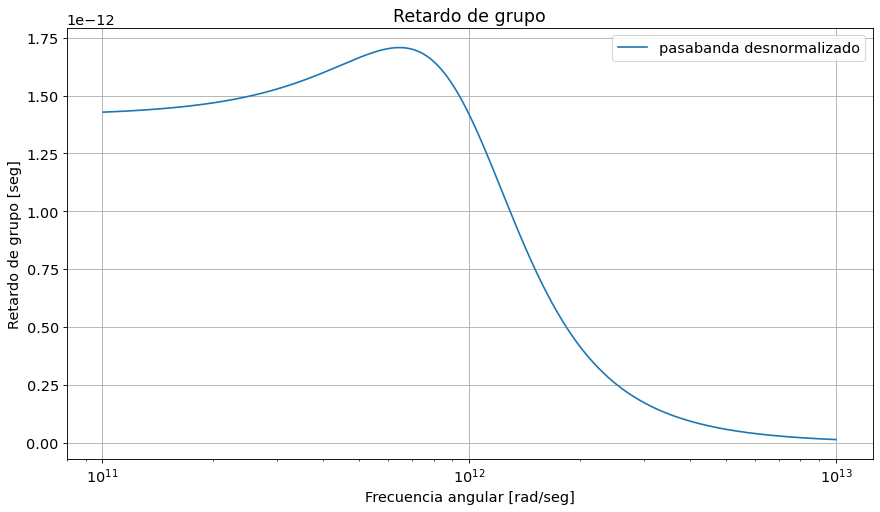

In [34]:
b = analyze_sys([H1_des], sys_name='pasabanda desnormalizado')

<img src="Spice1.png" display="block" margin=auto width=900>
<img src="Spice2.png" display="block" margin=auto width=900>
<img src="Spice3.png" display="block" margin=auto width=900>
<img src="Spice4.png" display="block" margin=auto width=900>
    